## simple RNN (predict sine -no noise)

In [1]:
import torch 
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import numpy as np


## data and data prep

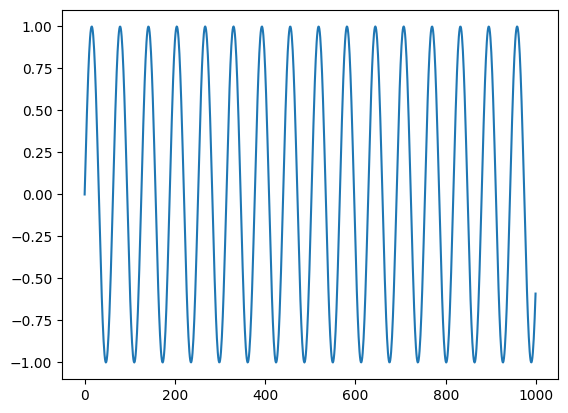

In [2]:
N = 1000

series = np.sin(0.1*np.arange(N)) #+ np.random.randn(N)*0.1
plt.plot(series)
plt.show()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [3]:
T = 10
D = 1
S = 1
M = 15
layers = 5

In [4]:
X,y = [],[]
for t in range(N-T):
    X.append(series[t:t+T])
    y.append(series[t+T])

In [5]:
N = len(X)
X = np.array(X).reshape(-1,T,D)
y = np.array(y).reshape(-1,1)

In [6]:
X_train,X_test = X[:N//2],X[N//2:]
y_train,y_test = y[:N//2],y[N//2:]

In [7]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

In [8]:
device = print('cuda:0' if torch.cuda.is_available() else 'cpu')

cuda:0


# define SimpleRNN

In [9]:
class SimpleRNN(nn.Module):
    def __init__(self, num_of_inputs,num_of_layers,num_of_hidden,num_of_outputs,bidirectional=False,activation='relu'):
        super(SimpleRNN,self).__init__()
        self.D = num_of_inputs
        self.L = num_of_layers
        self.M = num_of_hidden
        self.K = num_of_outputs 
        self.rnn = nn.RNN(input_size=self.D,
                          hidden_size=self.M,
                          num_layers=self.L,
                          bidirectional=bidirectional,
                          nonlinearity=activation,
                          batch_first=True) # if true shape is NxTxD otherwise it's TxNxD
        if bidirectional:
             self.L *=2

             self.fc = nn.Linear(self.M*2,self.K)
        else:
             self.fc = nn.Linear(self.M,self.K)


    
    def forward(self,X):
            
            #X dim = NxTxD
            #h0 dimensions LxNxM
            h0 = torch.zeros(self.L,X.size(0),self.M).to(device)
        
            out,_ = self.rnn(X,h0) #out dimensions: NxTxM
            # dims x torch.Size([495, 10, 1]), h0: torch.Size([5, 495, 256]) out torch.Size([495, 10, 256])
            #we want fc  input to be NxM ->NxK     
            x = self.fc(out[:,-1,:])
            
            return x


## model init, train and etc.

In [10]:
model = SimpleRNN(num_of_inputs=D,num_of_layers=layers,num_of_hidden=M,num_of_outputs=1,bidirectional=False).to(device)
criterion = nn.MSELoss().to(device)
optimizer = opt.Adam(model.parameters(),lr=0.001)
# scheduler = opt.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',patience=10)

train

In [11]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [12]:
train_losses = []
test_losses = []

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()

    out = model(X_train)
    loss = criterion(out,y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    out = model(X_test)
    loss1 = criterion(out,y_test)
    test_losses.append(loss1.item())
    print(f'train loss: {train_losses[-1]} test loss {test_losses[-1]}')
    # scheduler.step(loss)

train loss: 0.5539063215255737 test loss 0.5597041845321655
train loss: 0.5511754155158997 test loss 0.5569438338279724
train loss: 0.5485449433326721 test loss 0.5535948276519775
train loss: 0.5453368425369263 test loss 0.5503937005996704
train loss: 0.5422857999801636 test loss 0.5474048852920532
train loss: 0.5394521355628967 test loss 0.5444833040237427
train loss: 0.5366876125335693 test loss 0.5416454672813416
train loss: 0.5339999794960022 test loss 0.5390705466270447
train loss: 0.5315675139427185 test loss 0.5364989042282104
train loss: 0.5291479825973511 test loss 0.5356369018554688
train loss: 0.5283763408660889 test loss 0.534388542175293
train loss: 0.5272061228752136 test loss 0.5331137180328369
train loss: 0.5260123610496521 test loss 0.5318838953971863
train loss: 0.5248658657073975 test loss 0.5307160019874573
train loss: 0.5237816572189331 test loss 0.5295055508613586
train loss: 0.5226566195487976 test loss 0.5283143520355225
train loss: 0.5215510725975037 test loss 

In [13]:
xs = [x for x in range(epochs)]

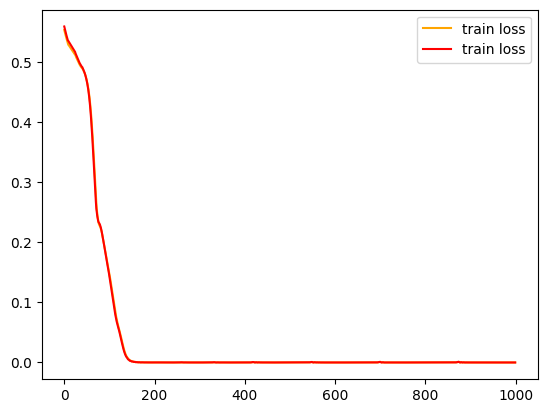

In [14]:
plt.plot(xs,train_losses,color='orange',label='train loss')
plt.plot(xs,test_losses,color='red',label='train loss')
plt.legend()
plt.show()

In [15]:
val_idx = 0 
validation_targets = y_test
validation_predictions = []
last_x = X_test[0]

In [16]:
while len(validation_predictions) < len(validation_targets) :
    inputs = last_x.view(1,-1,1)
    pred = model(inputs)
    validation_predictions.append(pred[0,0].item())
    val_idx += 1
    # last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
    last_x = torch.cat((last_x[1:],pred))
  

C:\Users\liora\AppData\Local\Temp\ipykernel_19632\245505276.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


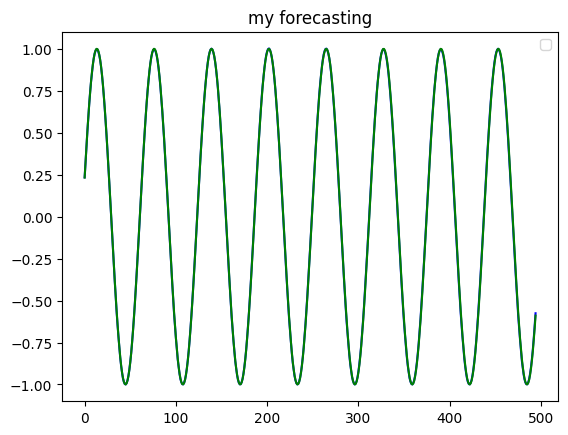

In [17]:
plt.title('my forecasting')
plt.plot(validation_predictions,color='blue')
plt.plot(validation_targets,color='green')
plt.legend()
plt.show()

In [18]:
#make predictions the right way
X_current = X_test[0]
predictions = []
for t in range(y_test.shape[0]):
    X_current = X_current.view(1, -1, 1)
    pred = model(X_current)
    predictions.append(pred.item())
    X_current = torch.cat((X_current.view(-1)[1:], pred.view(-1)))

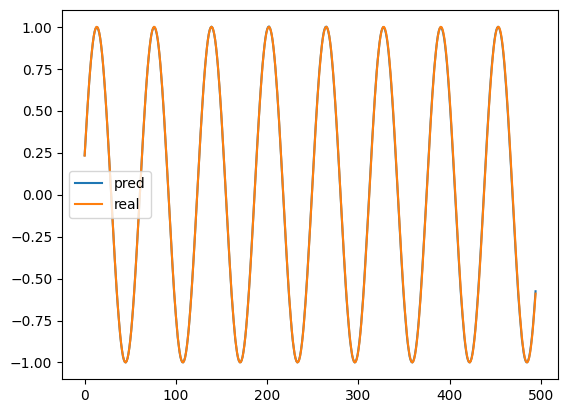

In [19]:
plt.plot(predictions, label='pred')
plt.plot(y_test, label='real')
plt.legend()
plt.show()